# 📊 Step 1 — Data Loading, Cleaning & Exploratory Analysis

> **Goal:** Understand what we are working with before touching any model. 
> Every modelling decision downstream is anchored here.

---
### Dataset at a glance
| Field | Detail |
|---|---|
| Source | `merged.xlsx` |
| Unit | Country-year panel |
| Rows | 2,803 |
| Target | `attacks` — count of terrorist incidents |
| Predictors | GDP **growth rate** (%), population, poverty, education, unemployment, inequality, 5 × World Governance Indicators |


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# ── Presentation style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#0f1117',
    'axes.facecolor'    : '#1a1d27',
    'axes.edgecolor'    : '#2e3347',
    'axes.labelcolor'   : '#c8ccd8',
    'axes.titlecolor'   : '#e8eaf0',
    'xtick.color'       : '#8890a8',
    'ytick.color'       : '#8890a8',
    'grid.color'        : '#2e3347',
    'grid.linewidth'    : 0.6,
    'text.color'        : '#e8eaf0',
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'figure.dpi'        : 130,
})

ACCENT   = '#4fc3f7'   # bright cyan
ACCENT2  = '#ff6b6b'   # coral red
ACCENT3  = '#a5d6a7'   # sage green
ACCENT4  = '#ffb74d'   # amber
GRAD     = ['#4fc3f7','#7986cb','#ff6b6b','#ffb74d','#a5d6a7','#f48fb1','#80cbc4','#ce93d8','#ef9a9a']

print('Libraries loaded ✓')

Libraries loaded ✓


## 1.1 Load the raw data

In [2]:
df_raw = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Terrorism_repo\notebooks\wgi\merged.xlsx")
print(f'Shape   : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Countries: {df_raw["country"].nunique()}')
print(f'Years   : {df_raw["year"].min()} – {df_raw["year"].max()}')
df_raw.head()

Shape   : 2,803 rows × 15 columns
Countries: 144
Years   : 1996 – 2020


,country,year,gdp,total_population,poverty_headcount,secondary_enrollment,unemployment_rate,inequality_measure,control_of_corruption,rule_of_law,government_effectiveness,political_stability,voice_and_accountability,regulatory_quality,attacks
0,afghanistan,2004,1.414118,23560654,NaN,19.21438,NaN,0.4095,0.0,0.075,0.25,0.1875,0.000000,0.107143,88.0
1,afghanistan,2005,11.229715,24404567,NaN,20.27351,NaN,0.4095,0.0,0.075,0.25,0.0625,0.000000,0.107143,155.0
2,afghanistan,2006,5.357403,25424094,NaN,29.52389,NaN,0.4095,0.0,0.025,0.00,0.0625,0.102000,0.107143,283.0
3,afghanistan,2009,21.390528,27466101,NaN,44.29995,NaN,0.3982,0.0,0.075,0.00,0.1250,0.100667,0.107143,503.0
4,afghanistan,2010,14.362441,28284089,NaN,50.44062,NaN,0.3948,0.0,0.075,0.00,0.1250,0.082667,0.107143,542.0


## 1.2 Missingness audit

Before imputing anything, we map *where* the gaps are — some variables (e.g. `poverty_headcount`) are sparsely collected by the World Bank and can be missing for >50 % of rows.

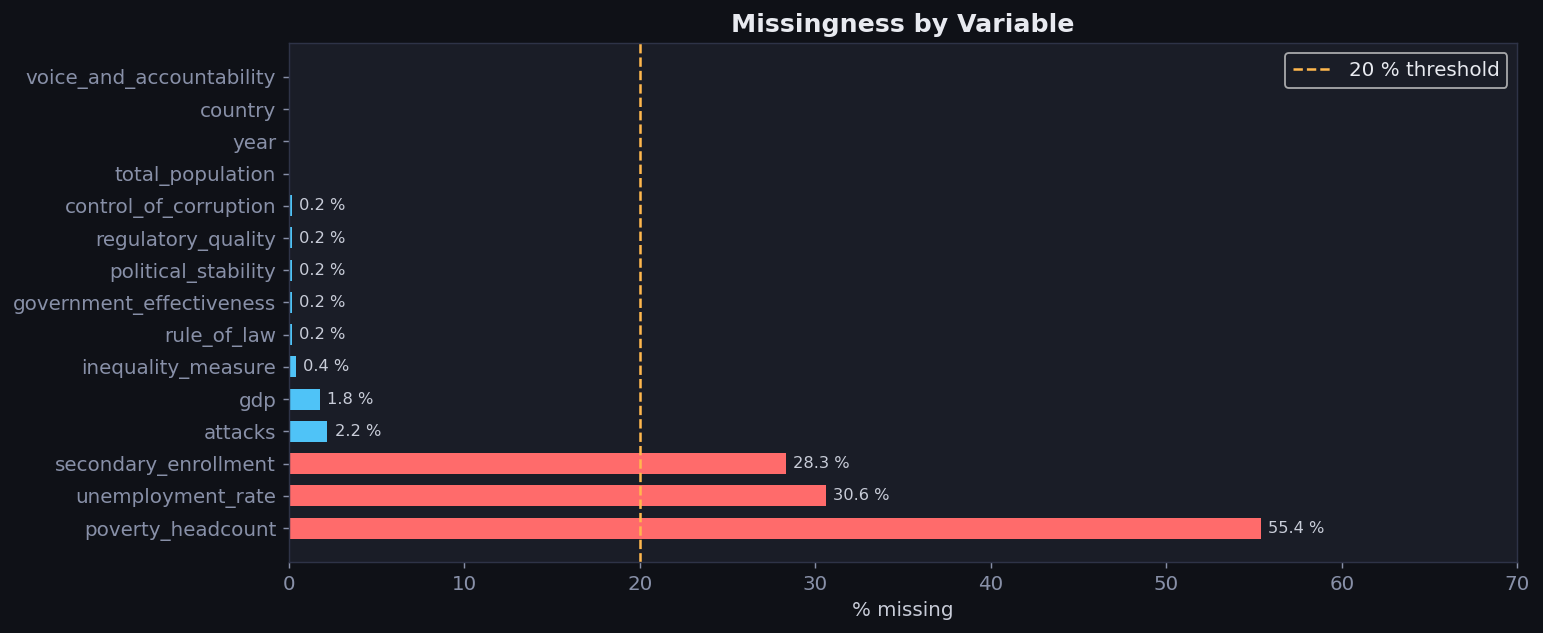

,Missing N,Missing %
poverty_headcount,1554,55.4
unemployment_rate,858,30.6
secondary_enrollment,792,28.3
attacks,61,2.2
gdp,50,1.8
inequality_measure,10,0.4
rule_of_law,6,0.2
government_effectiveness,6,0.2
political_stability,6,0.2
regulatory_quality,6,0.2


In [3]:
miss = df_raw.isnull().sum().sort_values(ascending=False)
miss_pct = (miss / len(df_raw) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(miss_pct.index, miss_pct.values,
               color=[ACCENT2 if v > 20 else ACCENT for v in miss_pct.values],
               edgecolor='none', height=0.65)
ax.axvline(20, color=ACCENT4, lw=1.4, ls='--', label='20 % threshold')
for bar, val in zip(bars, miss_pct.values):
    if val > 0:
        ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
                f'{val:.1f} %', va='center', fontsize=9, color='#c8ccd8')
ax.set_xlabel('% missing')
ax.set_title('Missingness by Variable')
ax.legend()
ax.set_xlim(0, 70)
plt.tight_layout()
plt.show()

pd.DataFrame({'Missing N': miss, 'Missing %': miss_pct}).query('`Missing N` > 0')

## 1.3 Cleaning pipeline

| Problem | Fix |
|---|---|
| Missing target rows | Drop — we cannot guess the outcome |
| Missing predictors | Fill with **within-country median**, then global median |
| Negative GDP growth | **Keep** — negative values represent economic contractions (recessions), which are economically meaningful |

In [4]:
PREDICTORS = [
    'gdp', 'total_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'control_of_corruption',
    'rule_of_law', 'government_effectiveness', 'political_stability',
    'voice_and_accountability', 'regulatory_quality',
]
TARGET = 'attacks'

df = df_raw.copy()
df = df.dropna(subset=[TARGET])                                   # drop missing target

for col in PREDICTORS:
    df[col] = df.groupby('country')[col].transform(
        lambda x: x.fillna(x.median())                           # within-country median
    )
    df[col] = df[col].fillna(df[col].median())                    # fallback global median

neg_gdp_growth = (df['gdp'] < 0).sum()
# GDP is GDP growth rate — negative values are valid (recessions); do NOT clip
# Previously clipped to 0 assuming data errors; corrected here

print(f'Rows after cleaning     : {len(df):,}')
print(f'Negative GDP growth rows: {neg_gdp_growth} (kept — represent contractions)')
print(f'Remaining NaNs          : {df[PREDICTORS].isnull().sum().sum()}')

Rows after cleaning     : 2,742
Negative GDP growth rows: 379 (kept — represent contractions)
Remaining NaNs          : 0


## 1.4 Target variable deep-dive

> **Key insight:** `attacks` is severely right-skewed with 47 % zeros and a maximum of 3,934. 
> This rules out vanilla OLS on the raw count — we need a transformation.

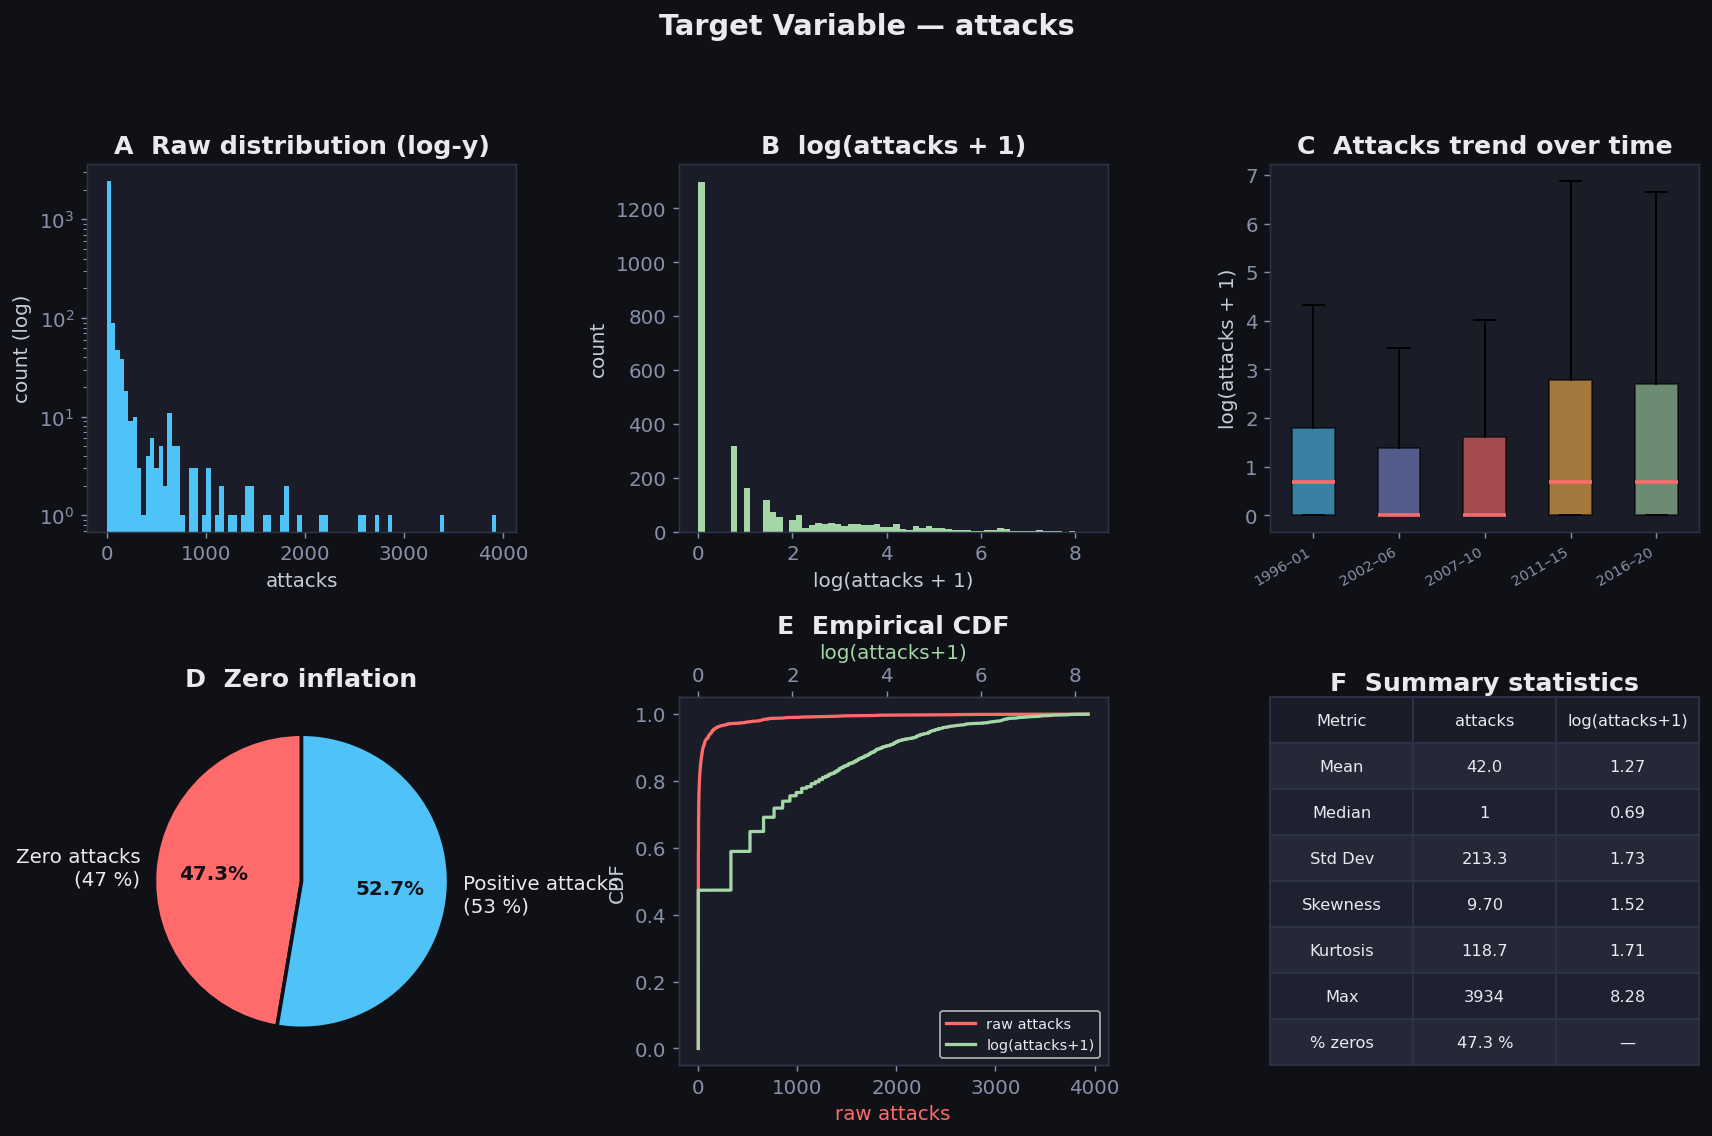


⚡ Skewness drops from 9.7 → 1.52 after log-transform


In [5]:
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# Panel A — raw histogram (log-y)
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df[TARGET], bins=90, color=ACCENT, edgecolor='none', log=True)
ax1.set_title('A  Raw distribution (log-y)')
ax1.set_xlabel('attacks')
ax1.set_ylabel('count (log)')

# Panel B — log-transformed
df['log_attacks'] = np.log1p(df[TARGET])
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df['log_attacks'], bins=60, color=ACCENT3, edgecolor='none')
ax2.set_title('B  log(attacks + 1)')
ax2.set_xlabel('log(attacks + 1)')
ax2.set_ylabel('count')

# Panel C — box-plot by year quintile
df['year_q'] = pd.qcut(df['year'], 5,
                        labels=['1996–01','2002–06','2007–10','2011–15','2016–20'])
ax3 = fig.add_subplot(gs[0, 2])
groups = [df.loc[df['year_q']==q, 'log_attacks'].values for q in df['year_q'].cat.categories]
bp = ax3.boxplot(groups, patch_artist=True, showfliers=False,
                 medianprops=dict(color=ACCENT2, lw=2))
for patch, clr in zip(bp['boxes'], GRAD):
    patch.set_facecolor(clr); patch.set_alpha(0.6)
ax3.set_xticklabels(df['year_q'].cat.categories, rotation=30, ha='right', fontsize=8)
ax3.set_title('C  Attacks trend over time')
ax3.set_ylabel('log(attacks + 1)')

# Panel D — zero inflation pie
ax4 = fig.add_subplot(gs[1, 0])
zero_pct  = (df[TARGET] == 0).mean() * 100
pos_pct   = 100 - zero_pct
wedges, texts, autotexts = ax4.pie(
    [zero_pct, pos_pct],
    labels=['Zero attacks\n(47 %)', 'Positive attacks\n(53 %)'],
    colors=[ACCENT2, ACCENT], autopct='%1.1f%%',
    startangle=90, wedgeprops=dict(edgecolor='#0f1117', linewidth=2))
for at in autotexts: at.set_color('#0f1117'); at.set_fontweight('bold')
ax4.set_title('D  Zero inflation')

# Panel E — CDF comparison: raw vs log
ax5 = fig.add_subplot(gs[1, 1])
sorted_raw = np.sort(df[TARGET])
sorted_log = np.sort(df['log_attacks'])
p          = np.linspace(0, 1, len(df))
ax5.plot(sorted_raw, p, color=ACCENT2,  lw=1.8, label='raw attacks')
ax5_r = ax5.twiny()
ax5_r.plot(sorted_log, p, color=ACCENT3, lw=1.8, label='log(attacks+1)')
ax5.set_xlabel('raw attacks', color=ACCENT2)
ax5_r.set_xlabel('log(attacks+1)', color=ACCENT3)
ax5.set_ylabel('CDF')
ax5.set_title('E  Empirical CDF')
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5_r.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# Panel F — summary stats table
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
stats_data = [
    ['Metric', 'attacks', 'log(attacks+1)'],
    ['Mean',        f"{df[TARGET].mean():.1f}",       f"{df['log_attacks'].mean():.2f}"],
    ['Median',      f"{df[TARGET].median():.0f}",     f"{df['log_attacks'].median():.2f}"],
    ['Std Dev',     f"{df[TARGET].std():.1f}",        f"{df['log_attacks'].std():.2f}"],
    ['Skewness',    f"{df[TARGET].skew():.2f}",       f"{df['log_attacks'].skew():.2f}"],
    ['Kurtosis',    f"{df[TARGET].kurt():.1f}",       f"{df['log_attacks'].kurt():.2f}"],
    ['Max',         f"{df[TARGET].max():.0f}",        f"{df['log_attacks'].max():.2f}"],
    ['% zeros',     f"{zero_pct:.1f} %",              '—'],
]
tbl = ax6.table(cellText=stats_data[1:], colLabels=stats_data[0],
                cellLoc='center', loc='center',
                bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1d27' if r == 0 else ('#252836' if r % 2 else '#1e2130'))
    cell.set_text_props(color='#e8eaf0')
    cell.set_edgecolor('#2e3347')
ax6.set_title('F  Summary statistics', pad=4)

fig.suptitle('Target Variable — attacks', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'\n⚡ Skewness drops from {df[TARGET].skew():.1f} → {df["log_attacks"].skew():.2f} after log-transform')

## 1.5 Top 20 countries by total attacks

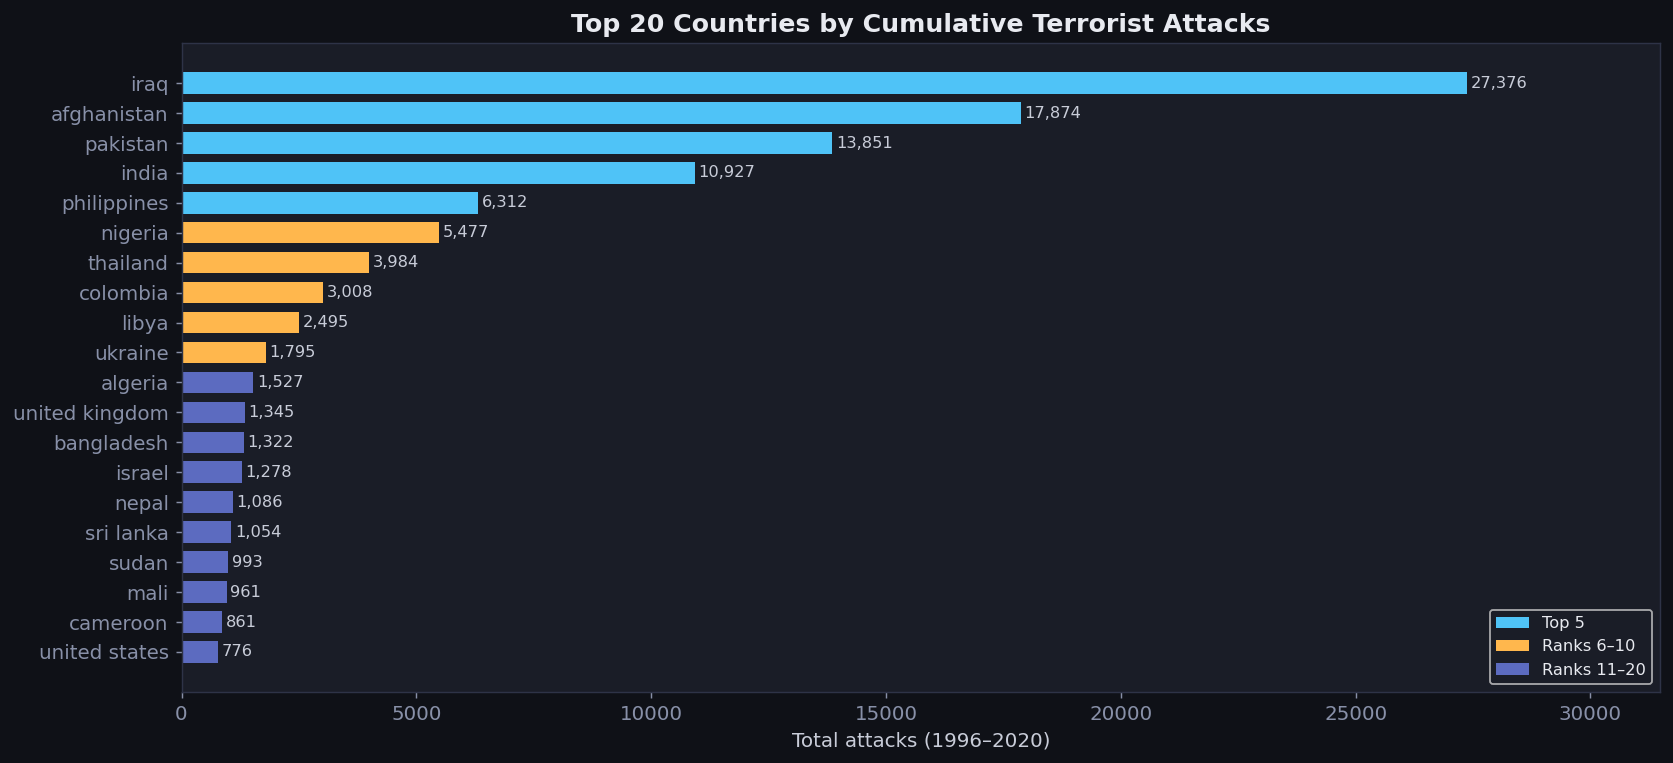

In [6]:
top20 = (df.groupby('country')[TARGET].sum()
           .sort_values(ascending=False).head(20))

fig, ax = plt.subplots(figsize=(13, 6))
colors  = [ACCENT if i < 5 else ACCENT4 if i < 10 else '#5c6bc0' for i in range(20)]
bars    = ax.barh(top20.index[::-1], top20.values[::-1],
                  color=colors[::-1], edgecolor='none', height=0.72)
for bar, val in zip(bars, top20.values[::-1]):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9, color='#c8ccd8')
ax.set_xlabel('Total attacks (1996–2020)')
ax.set_title('Top 20 Countries by Cumulative Terrorist Attacks')
ax.set_xlim(0, top20.max() * 1.15)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ACCENT,   label='Top 5'),
    Patch(facecolor=ACCENT4,  label='Ranks 6–10'),
    Patch(facecolor='#5c6bc0',label='Ranks 11–20'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 1.6 Save cleaned data for next notebooks

In [7]:
df.to_csv('df_clean.csv', index=False)
print(f'Saved: {len(df):,} rows, {df.shape[1]} columns')
print("Ready for Step 2 ✓")

Saved: 2,742 rows, 17 columns
Ready for Step 2 ✓


--- Normality Test (Shapiro-Wilk) ---
                Variable W-Stat    p-value Normal (α=0.05)
                     gdp 0.7725 4.6045e-52              No
        total_population 0.2520 2.6249e-74              No
       poverty_headcount 0.7490 9.5637e-54              No
    secondary_enrollment 0.9538 1.2858e-28              No
       unemployment_rate 0.8491 2.4633e-45              No
      inequality_measure 0.9821 4.2839e-18              No
   control_of_corruption 0.9051 2.6476e-38              No
             rule_of_law 0.9572 1.1460e-27              No
government_effectiveness 0.8807 1.0617e-41              No
     political_stability 0.9780 3.4316e-20              No
voice_and_accountability 0.9719 8.3055e-23              No
      regulatory_quality 0.9750 1.5736e-21              No
                 attacks 0.1882 5.5075e-76              No


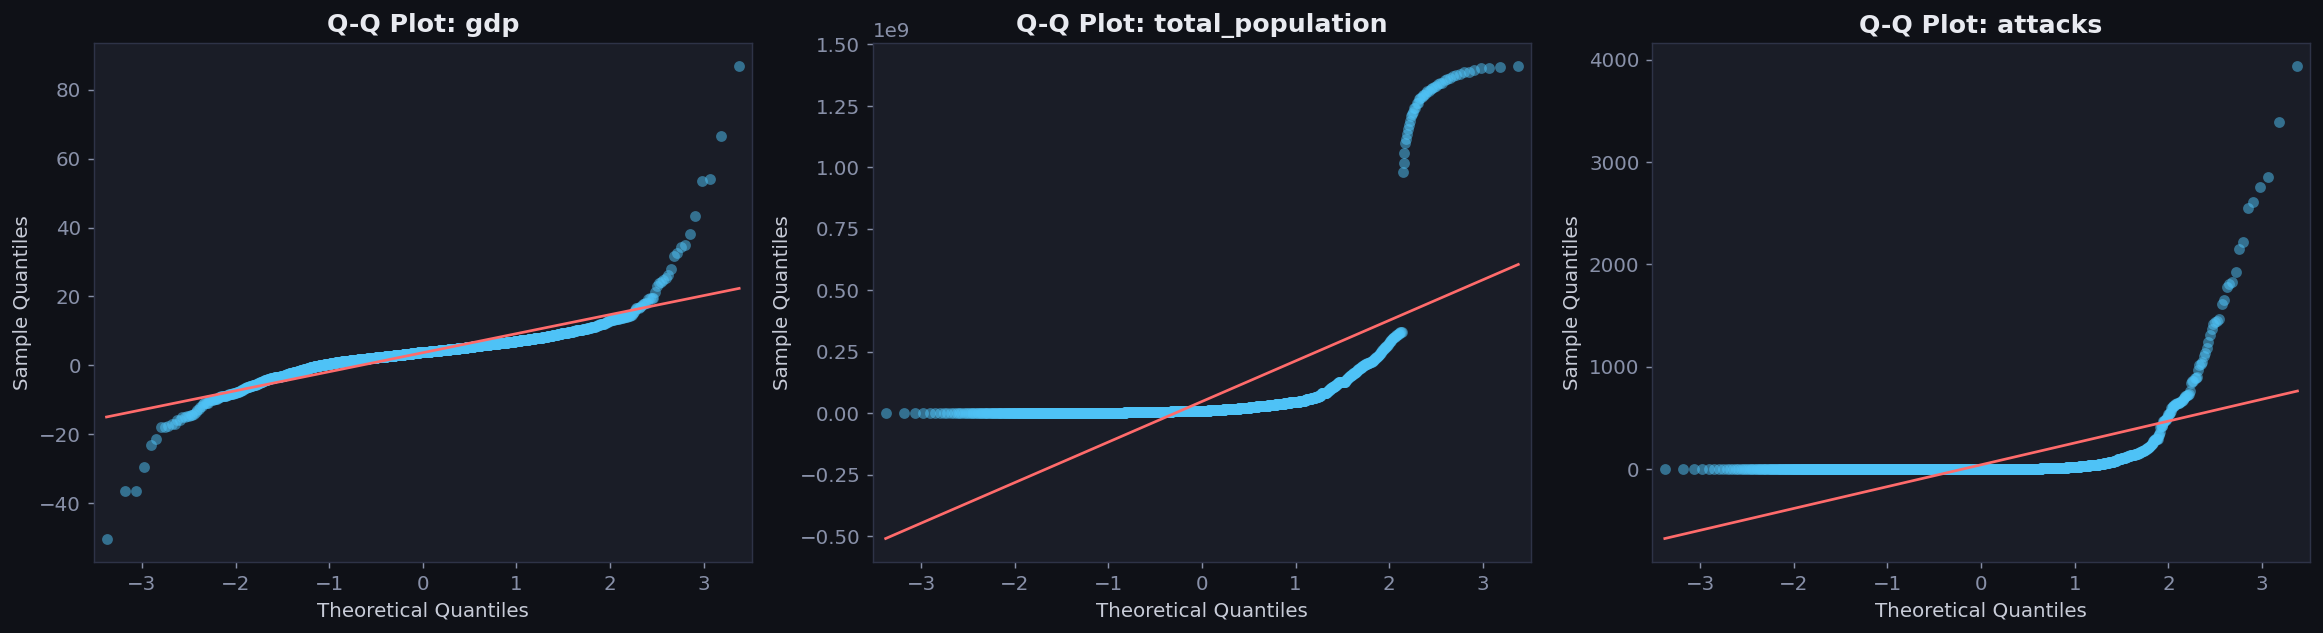


--- Inferential Statistics: Correlation with Target ---


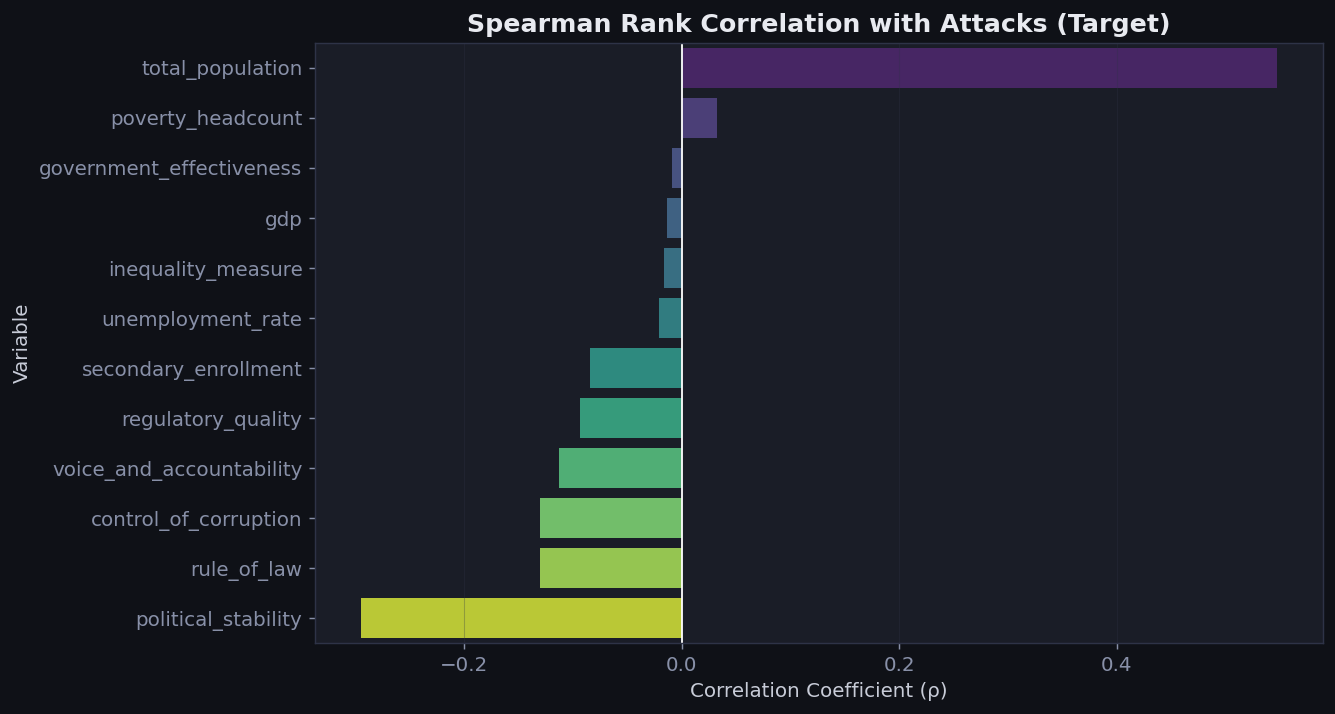

Significant Predictors (p < 0.05): 7 out of 12
                Variable  Spearman R     P-val (S)
        total_population    0.547066 6.909333e-214
    secondary_enrollment   -0.084487  9.424564e-06
      regulatory_quality   -0.093549  9.240238e-07
voice_and_accountability   -0.112329  3.679427e-09
   control_of_corruption   -0.129778  9.009780e-12
             rule_of_law   -0.130499  6.900468e-12
     political_stability   -0.294634  4.800112e-56


In [8]:
# ── Imports & Styles ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Use the project's visual style
plt.rcParams.update({
    'figure.facecolor'  : '#0f1117',
    'axes.facecolor'    : '#1a1d27',
    'axes.edgecolor'    : '#2e3347',
    'axes.labelcolor'   : '#c8ccd8',
    'axes.titlecolor'   : '#e8eaf0',
    'xtick.color'       : '#8890a8',
    'ytick.color'       : '#8890a8',
    'grid.color'        : '#2e3347',
    'text.color'        : '#e8eaf0',
})

ACCENT   = '#4fc3f7'   # bright cyan
ACCENT2  = '#ff6b6b'   # coral red
ACCENT3  = '#a5d6a7'   # sage green

# ── Load Data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('df_clean.csv')

PREDICTORS = [
    'gdp', 'total_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'control_of_corruption',
    'rule_of_law', 'government_effectiveness', 'political_stability',
    'voice_and_accountability', 'regulatory_quality',
]
TARGET = 'attacks'

# ── 1. Normality Testing ─────────────────────────────────────────────────────
print("--- Normality Test (Shapiro-Wilk) ---")
normality_results = []

for var in PREDICTORS + [TARGET]:
    # Sampling for Shapiro (limit 5000)
    data = df[var].dropna()
    if len(data) > 5000:
        data = data.sample(5000, random_state=42)
    
    stat, p = stats.shapiro(data)
    is_normal = "Yes" if p > 0.05 else "No"
    normality_results.append({
        'Variable': var,
        'W-Stat': f"{stat:.4f}",
        'p-value': f"{p:.4e}",
        'Normal (α=0.05)': is_normal
    })

# Display as table
norm_df = pd.DataFrame(normality_results)
print(norm_df.to_string(index=False))

# Visualization: Q-Q Plots for select variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sample_vars = ['gdp', 'total_population', TARGET]

for i, var in enumerate(sample_vars):
    sm.qqplot(df[var].dropna(), line='s', ax=axes[i])
    axes[i].set_title(f'Q-Q Plot: {var}')
    axes[i].get_lines()[1].set_color(ACCENT2) # regression line
    axes[i].get_lines()[0].set_markerfacecolor(ACCENT)
    axes[i].get_lines()[0].set_markeredgecolor('none')
    axes[i].get_lines()[0].set_alpha(0.5)

plt.tight_layout()
plt.show()

# ── 2. Inferential Statistics: Correlation Analysis ──────────────────────────
# Since variables are mostly non-normal, we use Spearman (Rank) correlation
print("\n--- Inferential Statistics: Correlation with Target ---")

correlation_data = []
for var in PREDICTORS:
    # Pearson (Linear)
    pearson_r, p_p = stats.pearsonr(df[var], df[TARGET])
    # Spearman (Monotonic)
    spearman_r, p_s = stats.spearmanr(df[var], df[TARGET])
    
    correlation_data.append({
        'Variable': var,
        'Pearson R': pearson_r,
        'P-val (P)': p_p,
        'Spearman R': spearman_r,
        'P-val (S)': p_s
    })

corr_df = pd.DataFrame(correlation_data).sort_values('Spearman R', ascending=False)

# Visualize Correlations
plt.figure(figsize=(10, 6))
sns.barplot(data=corr_df, x='Spearman R', y='Variable', 
            palette='viridis', edgecolor='none')
plt.axvline(0, color='white', lw=1)
plt.title('Spearman Rank Correlation with Attacks (Target)')
plt.xlabel('Correlation Coefficient (ρ)')
plt.grid(axis='x', alpha=0.3)
plt.show()

# Print Significant Relationships
sig_corr = corr_df[corr_df['P-val (S)'] < 0.05]
print(f"Significant Predictors (p < 0.05): {len(sig_corr)} out of {len(PREDICTORS)}")
print(sig_corr[['Variable', 'Spearman R', 'P-val (S)']].to_string(index=False))

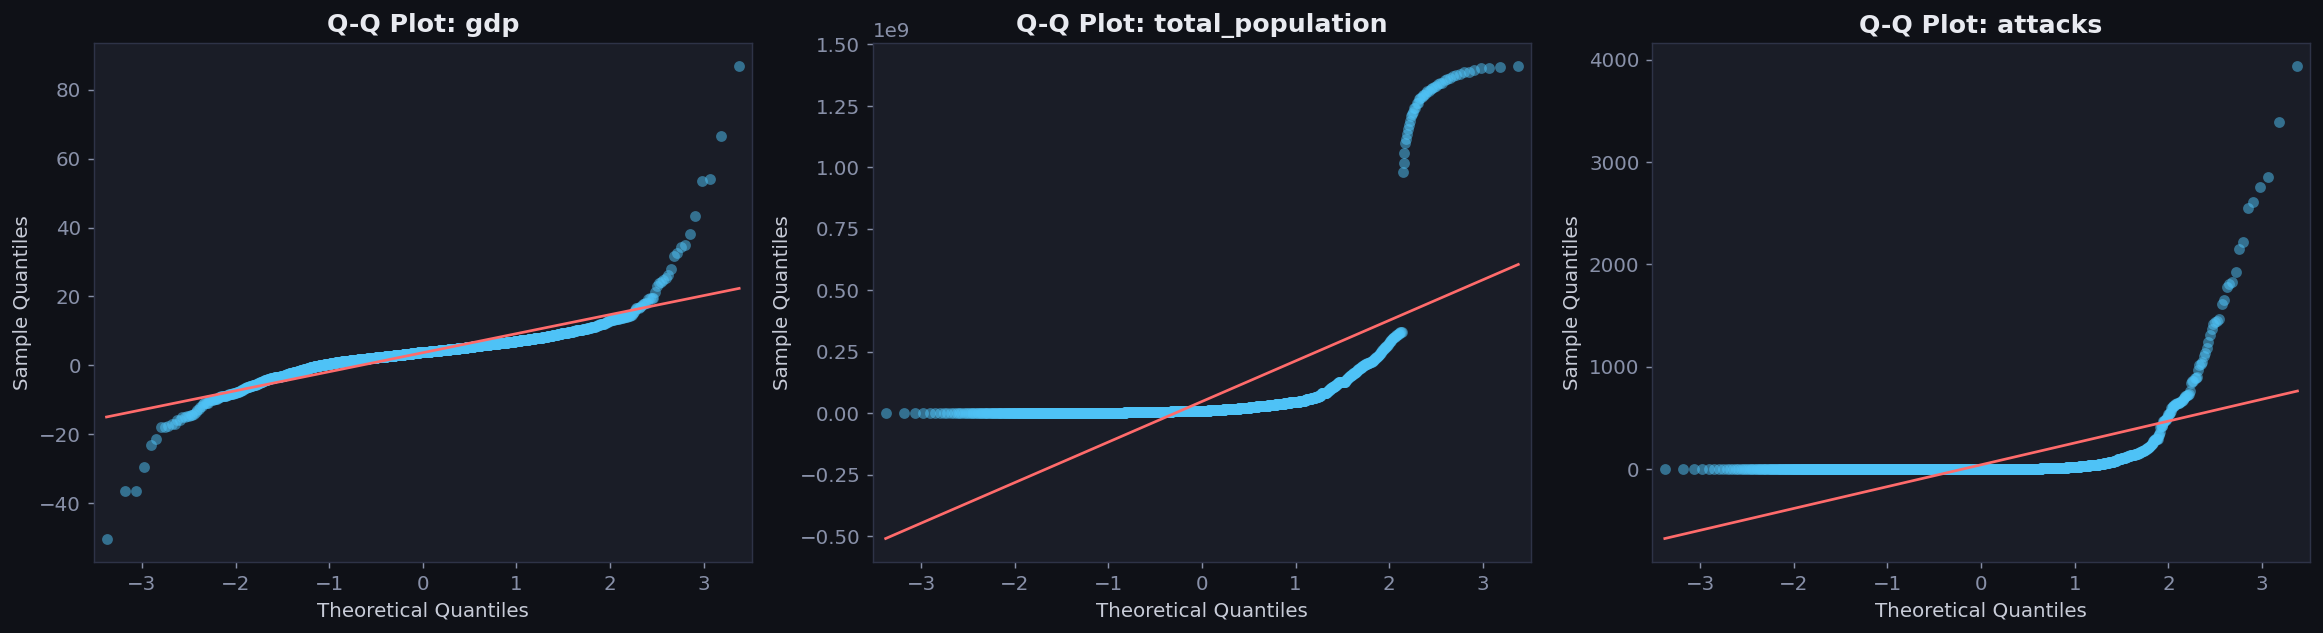

In [9]:
# Visualization: Q-Q Plots for select variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sample_vars = ['gdp', 'total_population', TARGET]

for i, var in enumerate(sample_vars):
    sm.qqplot(df[var].dropna(), line='s', ax=axes[i])
    axes[i].set_title(f'Q-Q Plot: {var}')
    axes[i].get_lines()[1].set_color(ACCENT2) # regression line
    axes[i].get_lines()[0].set_markerfacecolor(ACCENT)
    axes[i].get_lines()[0].set_markeredgecolor('none')
    axes[i].get_lines()[0].set_alpha(0.5)

plt.tight_layout()
plt.show()

--- Normality Test (Shapiro-Wilk) ---


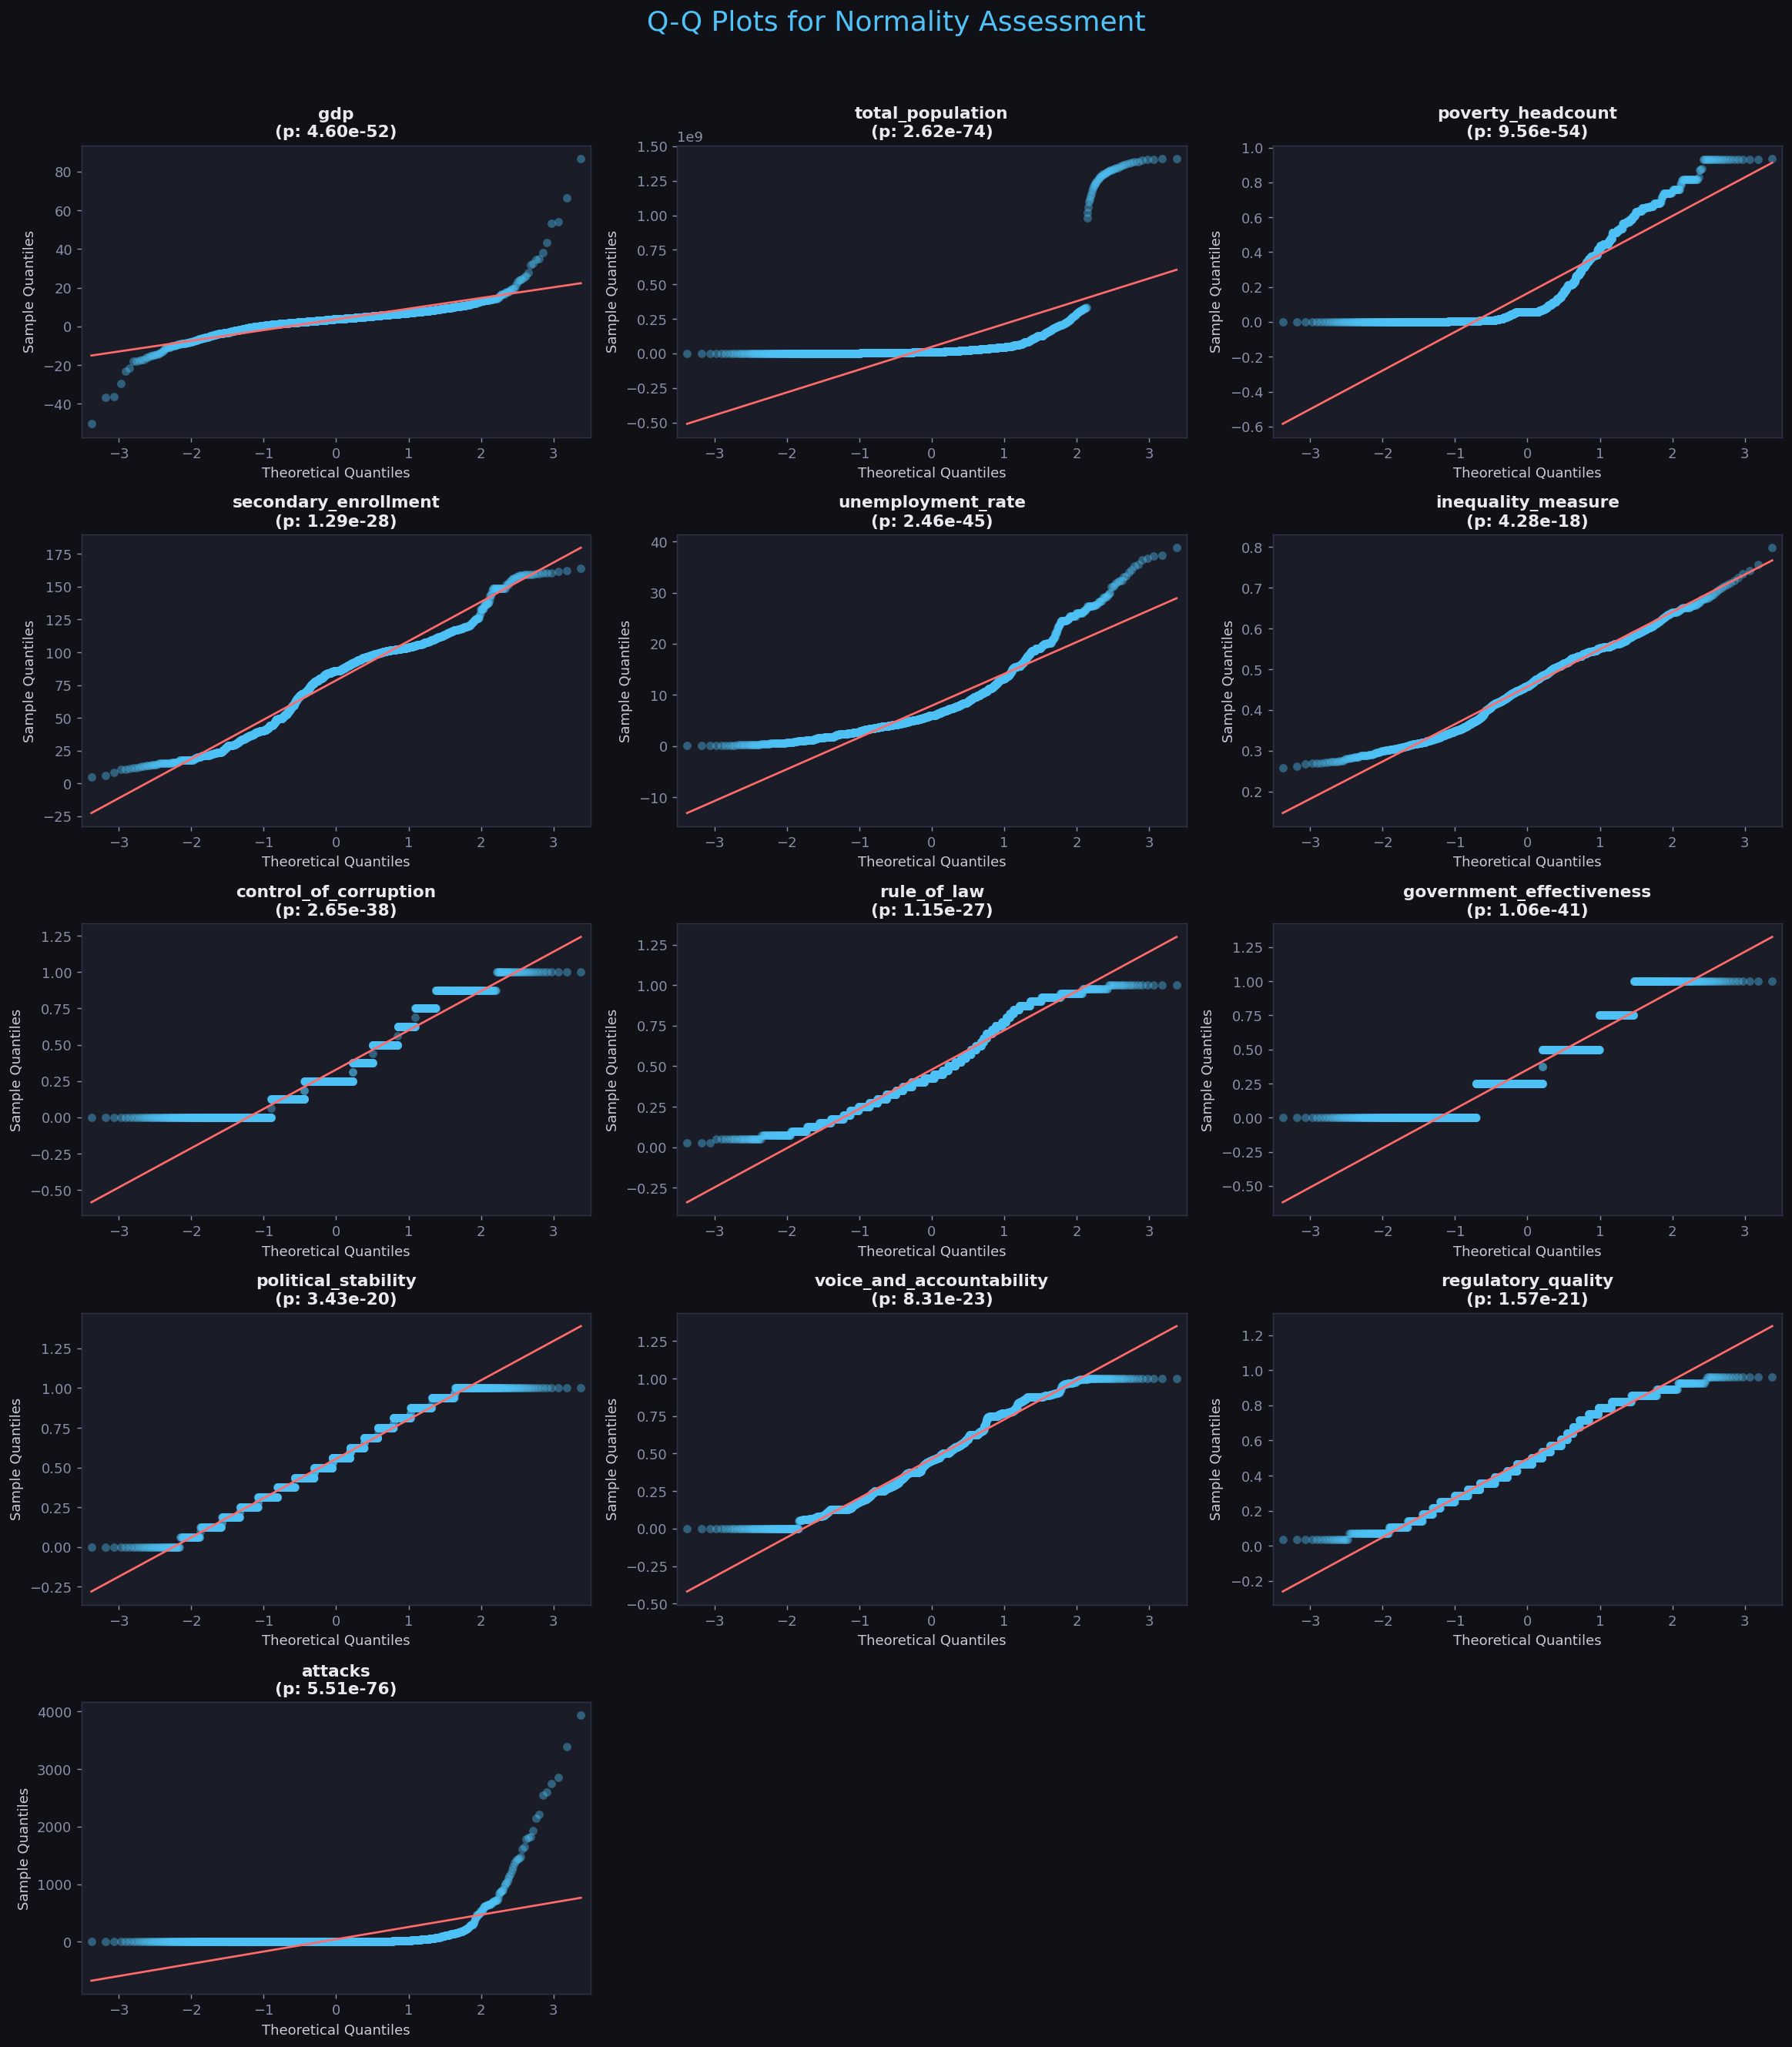

                Variable   W-Stat      p-value Normal (α=0.05)
                     gdp 0.772496 4.604507e-52              No
        total_population 0.252013 2.624854e-74              No
       poverty_headcount 0.749009 9.563721e-54              No
    secondary_enrollment 0.953807 1.285818e-28              No
       unemployment_rate 0.849064 2.463303e-45              No
      inequality_measure 0.982135 4.283878e-18              No
   control_of_corruption 0.905115 2.647566e-38              No
             rule_of_law 0.957235 1.145975e-27              No
government_effectiveness 0.880657 1.061699e-41              No
     political_stability 0.977979 3.431606e-20              No
voice_and_accountability 0.971860 8.305515e-23              No
      regulatory_quality 0.974986 1.573639e-21              No
                 attacks 0.188242 5.507508e-76              No


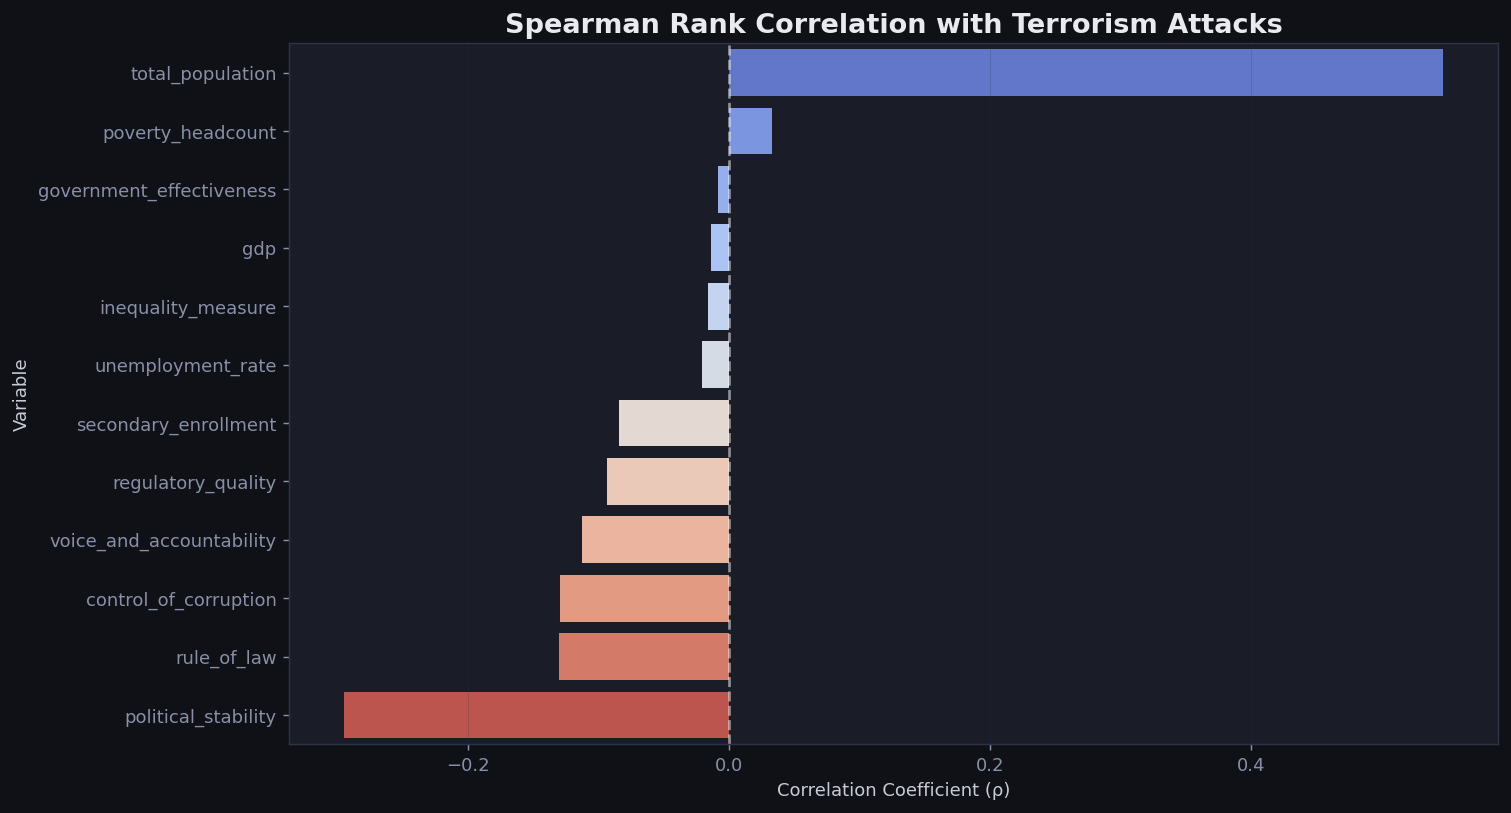


--- Significant Predictors (p < 0.05) ---
                Variable  Spearman_Rho       p_value
        total_population      0.547066 6.909333e-214
    secondary_enrollment     -0.084487  9.424564e-06
      regulatory_quality     -0.093549  9.240238e-07
voice_and_accountability     -0.112329  3.679427e-09
   control_of_corruption     -0.129778  9.009780e-12
             rule_of_law     -0.130499  6.900468e-12
     political_stability     -0.294634  4.800112e-56


In [10]:
# ── Imports & Styles ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import math

# Use the project's visual style
plt.rcParams.update({
    'figure.facecolor'  : '#0f1117',
    'axes.facecolor'    : '#1a1d27',
    'axes.edgecolor'    : '#2e3347',
    'axes.labelcolor'   : '#c8ccd8',
    'axes.titlecolor'   : '#e8eaf0',
    'xtick.color'       : '#8890a8',
    'ytick.color'       : '#8890a8',
    'grid.color'        : '#2e3347',
    'text.color'        : '#e8eaf0',
    'font.size'         : 10
})

ACCENT   = '#4fc3f7'   # bright cyan
ACCENT2  = '#ff6b6b'   # coral red

# ── Load Data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('df_clean.csv')

PREDICTORS = [
    'gdp', 'total_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'control_of_corruption',
    'rule_of_law', 'government_effectiveness', 'political_stability',
    'voice_and_accountability', 'regulatory_quality',
]
TARGET = 'attacks'
ALL_VARS = PREDICTORS + [TARGET]

# ── 1. Comprehensive Normality Diagnostics (Q-Q Plots) ───────────────────────
n_vars = len(ALL_VARS)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

print("--- Normality Test (Shapiro-Wilk) ---")
normality_results = []

for i, var in enumerate(ALL_VARS):
    data = df[var].dropna()
    
    # Statistical Test (using sample if N > 5000)
    test_data = data.sample(min(len(data), 5000), random_state=42)
    sw_stat, sw_p = stats.shapiro(test_data)
    
    # Visual Diagnostic: Q-Q Plot
    sm.qqplot(data, line='s', ax=axes[i])
    axes[i].set_title(f'{var}\n(p: {sw_p:.2e})', fontsize=12, fontweight='bold')
    
    # Style the Q-Q plot to match project colors
    axes[i].get_lines()[1].set_color(ACCENT2) # The 45-degree line
    axes[i].get_lines()[0].set_markerfacecolor(ACCENT) # The data points
    axes[i].get_lines()[0].set_markeredgecolor('none')
    axes[i].get_lines()[0].set_alpha(0.4)
    
    normality_results.append({
        'Variable': var,
        'W-Stat': sw_stat,
        'p-value': sw_p,
        'Normal (α=0.05)': "Yes" if sw_p > 0.05 else "No"
    })

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Q-Q Plots for Normality Assessment', fontsize=20, y=1.02, color=ACCENT)
plt.tight_layout()
plt.show()

# Display Table Summary
norm_df = pd.DataFrame(normality_results)
print(norm_df.to_string(index=False))

# ── 2. Inferential Statistics: Correlation Analysis ──────────────────────────
# Given that most variables are likely non-normal (p < 0.05), Spearman is used.
correlations = []
for var in PREDICTORS:
    rho, p_val = stats.spearmanr(df[var], df[TARGET], nan_policy='omit')
    correlations.append({'Variable': var, 'Spearman_Rho': rho, 'p_value': p_val})

corr_df = pd.DataFrame(correlations).sort_values('Spearman_Rho', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=corr_df, x='Spearman_Rho', y='Variable', palette='coolwarm', edgecolor='none')
plt.axvline(0, color='white', linestyle='--', alpha=0.5)
plt.title('Spearman Rank Correlation with Terrorism Attacks', fontsize=15)
plt.xlabel('Correlation Coefficient (ρ)')
plt.grid(axis='x', alpha=0.2)
plt.show()

print("\n--- Significant Predictors (p < 0.05) ---")
print(corr_df[corr_df['p_value'] < 0.05].to_string(index=False))

The Normality Verdict: "Non-Normal Across the Board"

All variables failed the Shapiro-Wilk test ($p < 0.05$), meaning they do not follow a bell-curve (Gaussian) distribution. This is standard for real-world social science data:

Extreme Skew: attacks and total_population are the most distorted. They follow a "power law," where a few observations have huge values and most have very small ones.

Economic Shocks: gdp and unemployment have "fat tails," reflecting the frequency of extreme economic events (recessions/booms) compared to a theoretical normal curve.

Governance Clusters: WGI indicators are the "most normal" but are likely rejected due to a "bimodal" split—countries tend to cluster at either high or low institutional quality.

--- Running Inferential Tests (Spearman & Mann-Whitney U) ---
                Variable  Spearman_Rho  Corr_P_Value   MWU_P_Value Significant
        total_population      0.547066 6.909333e-214 9.188327e-125         Yes
       poverty_headcount      0.033003  8.401795e-02  1.309694e-05          No
government_effectiveness     -0.008796  6.452312e-01  8.864069e-02          No
                     gdp     -0.013690  4.736422e-01  5.543000e-01          No
      inequality_measure     -0.016071  4.002355e-01  1.141454e-01          No
       unemployment_rate     -0.020986  2.719631e-01  9.716332e-01          No
    secondary_enrollment     -0.084487  9.424564e-06  7.964150e-04         Yes
      regulatory_quality     -0.093549  9.240238e-07  2.581947e-04         Yes
voice_and_accountability     -0.112329  3.679427e-09  3.385829e-07         Yes
   control_of_corruption     -0.129778  9.009780e-12  9.748845e-09         Yes
             rule_of_law     -0.130499  6.900468e-12  9.777393e-11   

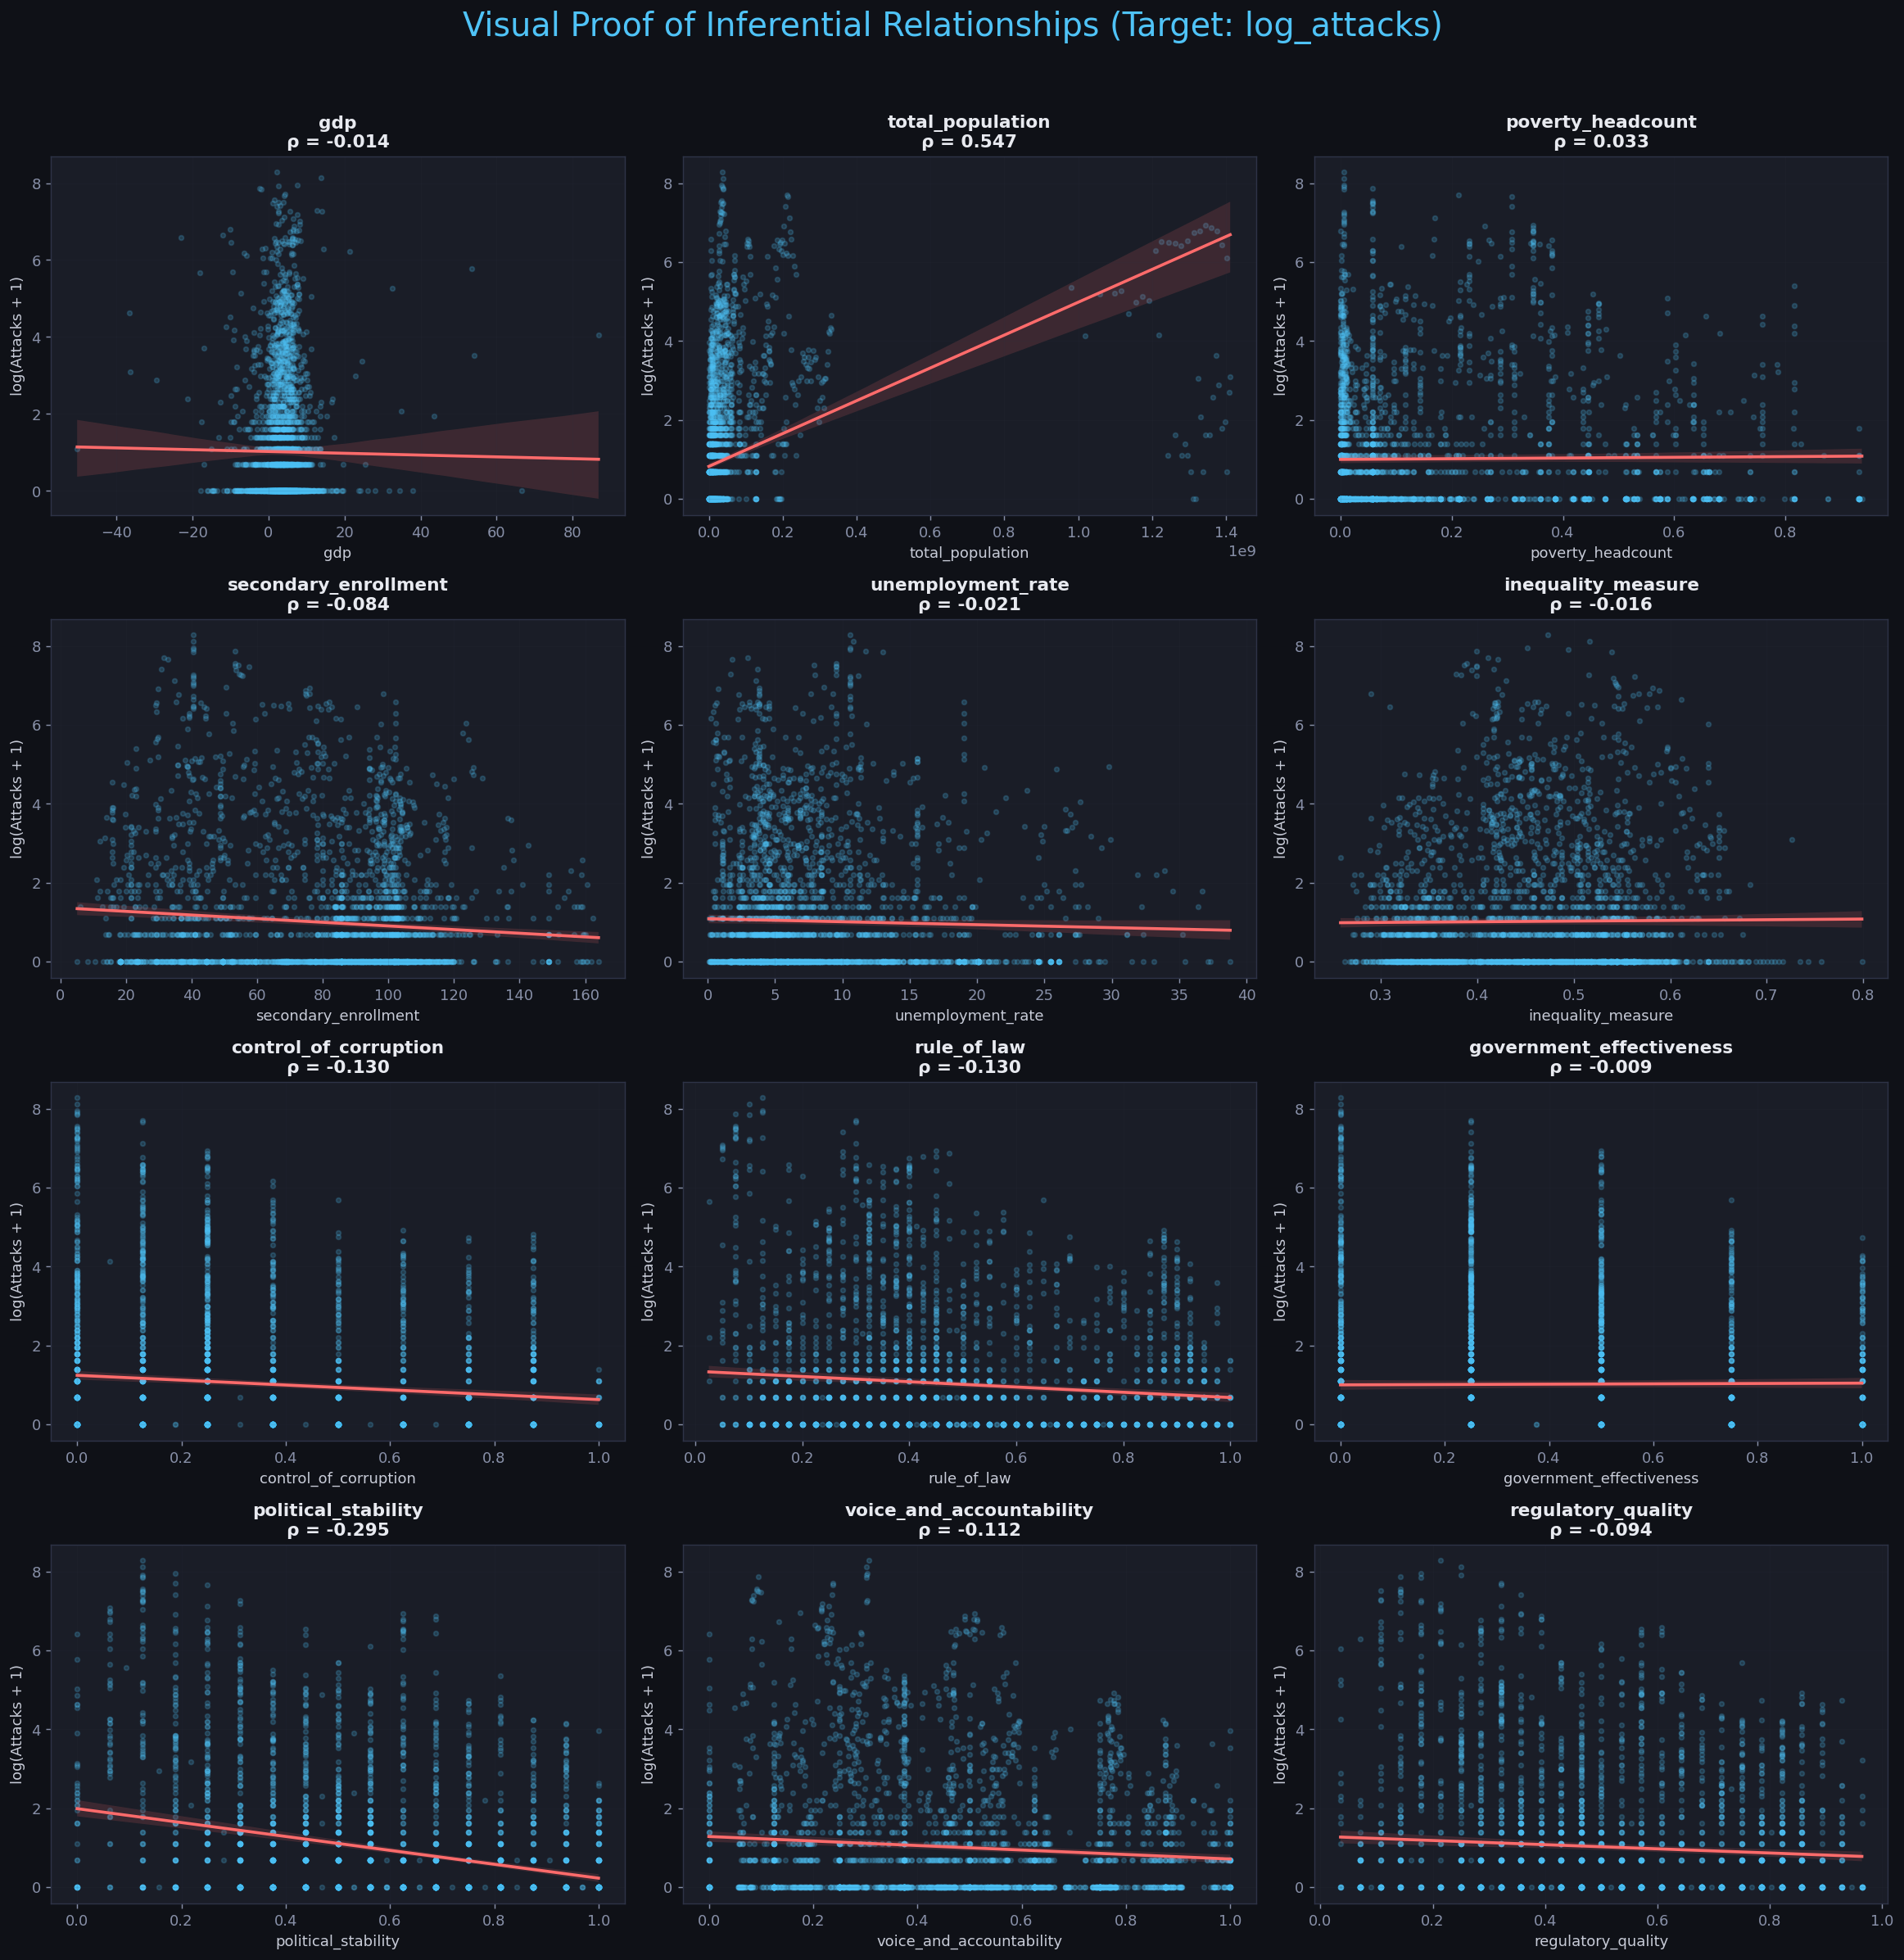

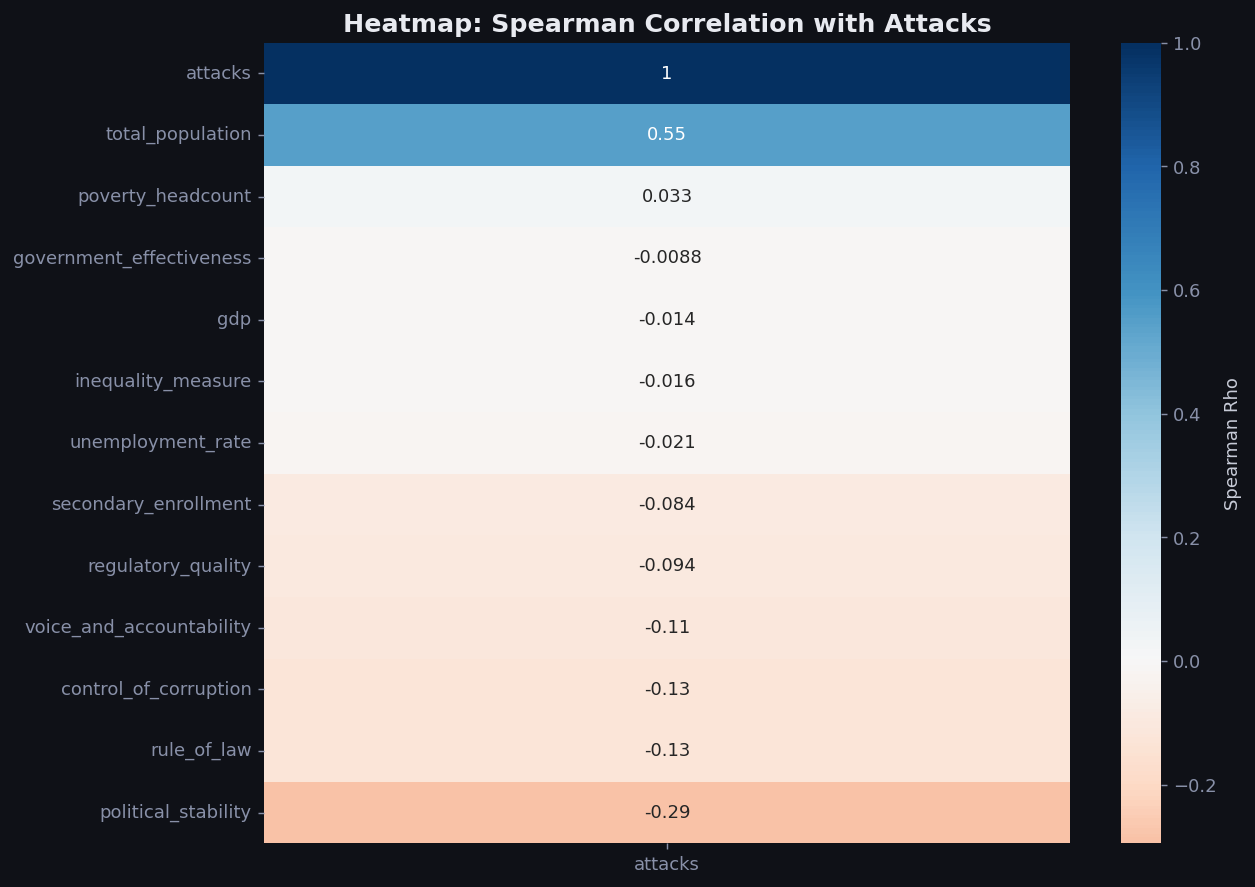

In [11]:
# ── Imports & Setup ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import math

# Project Visual Style
plt.rcParams.update({
    'figure.facecolor'  : '#0f1117',
    'axes.facecolor'    : '#1a1d27',
    'axes.edgecolor'    : '#2e3347',
    'axes.labelcolor'   : '#c8ccd8',
    'axes.titlecolor'   : '#e8eaf0',
    'xtick.color'       : '#8890a8',
    'ytick.color'       : '#8890a8',
    'grid.color'        : '#2e3347',
    'text.color'        : '#e8eaf0'
})

ACCENT   = '#4fc3f7'   # bright cyan
ACCENT2  = '#ff6b6b'   # coral red
ACCENT3  = '#a5d6a7'   # sage green

# Load data
df = pd.read_csv('df_clean.csv')
# Use log_attacks for visualization to handle skewness
df['log_attacks'] = np.log1p(df['attacks'])

PREDICTORS = [
    'gdp', 'total_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'control_of_corruption',
    'rule_of_law', 'government_effectiveness', 'political_stability',
    'voice_and_accountability', 'regulatory_quality',
]
TARGET = 'attacks'

# ── 1. Inferential Statistical Testing ────────────────────────────────────────
inferential_results = []

print("--- Running Inferential Tests (Spearman & Mann-Whitney U) ---")

for var in PREDICTORS:
    # A. Spearman Correlation (Relationship Strength)
    rho, rho_p = stats.spearmanr(df[var], df[TARGET], nan_policy='omit')
    
    # B. Mann-Whitney U Test (Group Difference)
    # Split predictor into 'High' and 'Low' groups based on median
    median_val = df[var].median()
    high_grp = df[df[var] > median_val][TARGET]
    low_grp  = df[df[var] <= median_val][TARGET]
    
    u_stat, u_p = stats.mannwhitneyu(high_grp, low_grp, alternative='two-sided')
    
    inferential_results.append({
        'Variable': var,
        'Spearman_Rho': rho,
        'Corr_P_Value': rho_p,
        'MWU_P_Value': u_p,
        'Significant': 'Yes' if rho_p < 0.05 else 'No'
    })

results_df = pd.DataFrame(inferential_results).sort_values('Spearman_Rho', ascending=False)
print(results_df.to_string(index=False))

# ── 2. Visual Proof: Bivariate Relationship Grid ──────────────────────────────
n_vars = len(PREDICTORS)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

for i, var in enumerate(PREDICTORS):
    # Regression Plot (Visual Proof of Trend)
    sns.regplot(
        data=df, x=var, y='log_attacks', 
        ax=axes[i],
        scatter_kws={'alpha': 0.2, 'color': ACCENT, 's': 10},
        line_kws={'color': ACCENT2, 'lw': 2},
        robust=True # Handles outliers in non-normal data
    )
    
    # Annotate with Spearman Rho
    rho = results_df.loc[results_df['Variable'] == var, 'Spearman_Rho'].values[0]
    axes[i].set_title(f"{var}\nρ = {rho:.3f}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel('log(Attacks + 1)')
    axes[i].grid(True, alpha=0.1)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Visual Proof of Inferential Relationships (Target: log_attacks)', 
             fontsize=22, y=1.02, color=ACCENT)
plt.tight_layout()
plt.show()

# ── 3. Summary Correlation Heatmap ───────────────────────────────────────────
plt.figure(figsize=(10, 8))
corr_matrix = df[PREDICTORS + [TARGET]].corr(method='spearman')
sns.heatmap(corr_matrix[[TARGET]].sort_values(by=TARGET, ascending=False), 
            annot=True, cmap='RdBu', center=0, cbar_kws={'label': 'Spearman Rho'})
plt.title('Heatmap: Spearman Correlation with Attacks')
plt.show()

Brief Interpretation

The Scale Effect (total_population): With a Rho of 0.55, this is your strongest predictor. It confirms a "scale effect": more people simply provide more targets and more opportunities for conflict to be recorded.

The Stability Deterrent (political_stability): This is the strongest governance factor (-0.29). It suggests that the absence of institutional violence and "coups" is the most direct preventative measure against terrorism.

Governance & Liberty: Variables like rule_of_law and voice_and_accountability show significant negative correlations. This implies that institutional quality and civil liberties act as "safety valves" for social grievances.

The "Insignificant" Group: Variables like gdp, poverty, and unemployment have $p$-values > 0.05. In this raw, one-to-one comparison, they do not show a consistent monotonic relationship with attacks.

Why Keep All Variables?

Multivariate Context: A variable can look "useless" alone but become a powerful predictor when combined with others (avoiding Omitted Variable Bias).

Interactions: We need the "insignificant" base variables (like poverty) to calculate the "significant" interaction terms (like poverty × weak governance).

Non-Linearity: Spearman only sees straight lines. Advanced models in Step 6 look for U-shapes or "tipping points" where economic variables might suddenly matter.

Internal Trends: Current tests compare different countries. Step 6 uses Fixed Effects to see how a single country’s attacks change as its economy or governance fluctuates over time.

Scientific Rigor: Reporting that a factor (like inequality) is not significant is a valuable finding that prevents "cherry-picking" data to fit a narrative.


--- Skewness & Kurtosis Analysis ---


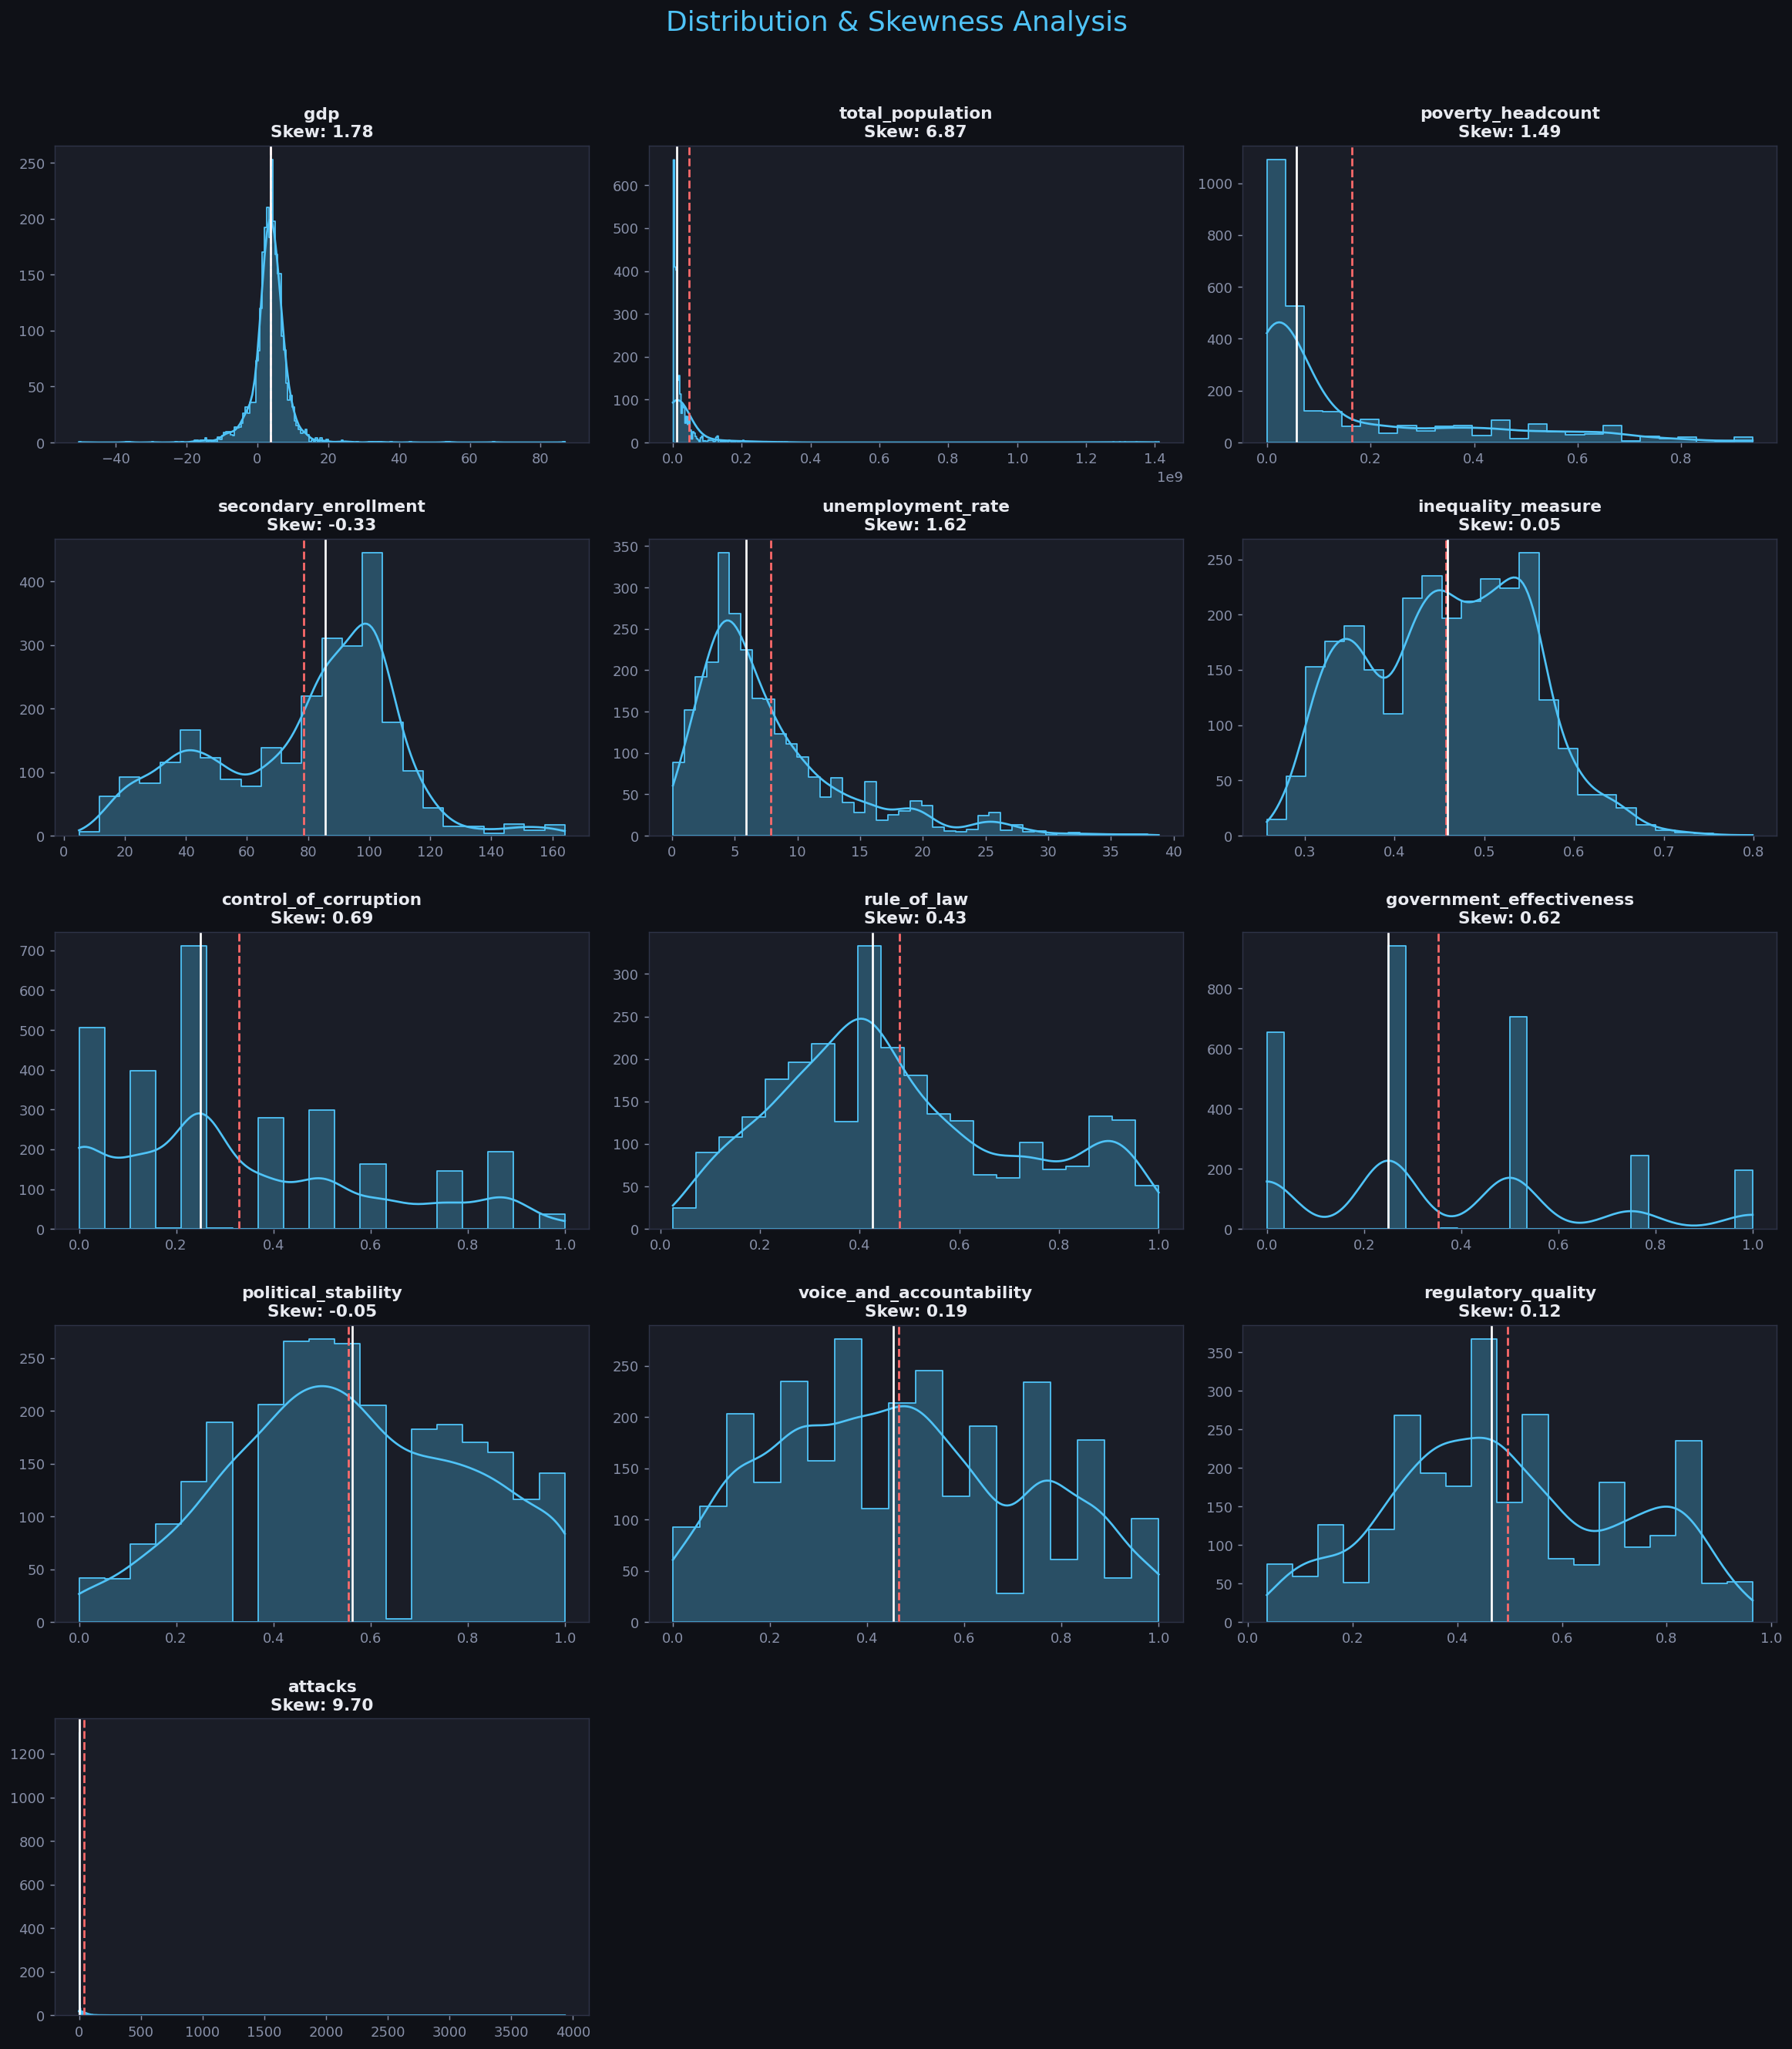

                Variable  Skewness   Kurtosis       Distribution
                     gdp  1.778554  38.598337      Highly Skewed
        total_population  6.870749  49.066512      Highly Skewed
       poverty_headcount  1.488423   1.215667      Highly Skewed
    secondary_enrollment -0.327355  -0.389085 Fairly Symmetrical
       unemployment_rate  1.617033   2.794977      Highly Skewed
      inequality_measure  0.052715  -0.643954 Fairly Symmetrical
   control_of_corruption  0.694686  -0.431962  Moderately Skewed
             rule_of_law  0.430753  -0.703861 Fairly Symmetrical
government_effectiveness  0.624516  -0.289460  Moderately Skewed
     political_stability -0.045307  -0.714036 Fairly Symmetrical
voice_and_accountability  0.194161  -0.881194 Fairly Symmetrical
      regulatory_quality  0.115082  -0.823378 Fairly Symmetrical
                 attacks  9.701795 118.730473      Highly Skewed


In [12]:
# ── 3. Skewness & Distribution Analysis ──────────────────────────────────────
n_vars = len(ALL_VARS)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

skew_results = []

print("\n--- Skewness & Kurtosis Analysis ---")

for i, var in enumerate(ALL_VARS):
    data = df[var].dropna()
    
    # Calculate values
    skew_val = data.skew()
    kurt_val = data.kurtosis()
    
    # Plotting Histogram + KDE
    sns.histplot(data, kde=True, ax=axes[i], color=ACCENT, element="step", alpha=0.3)
    
    # Add Mean and Median lines for visual skew reference
    axes[i].axvline(data.mean(), color=ACCENT2, linestyle='--', label=f'Mean: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='#ffffff', linestyle='-', label=f'Median: {data.median():.2f}')
    
    # Formatting
    axes[i].set_title(f'{var}\nSkew: {skew_val:.2f}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    
    # Interpretation
    if abs(skew_val) < 0.5:
        desc = "Fairly Symmetrical"
    elif abs(skew_val) <= 1:
        desc = "Moderately Skewed"
    else:
        desc = "Highly Skewed"
        
    skew_results.append({
        'Variable': var,
        'Skewness': skew_val,
        'Kurtosis': kurt_val,
        'Distribution': desc
    })

# Cleanup
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution & Skewness Analysis', fontsize=20, y=1.02, color=ACCENT)
plt.tight_layout()
plt.show()

# Display Results Table
skew_df = pd.DataFrame(skew_results)
print(skew_df.to_string(index=False))